# Data combiner
Combine all data in a single csv to be used for machine learning

In [23]:
# I will need the tokenizer data, the morpheme data, and the resource-level data

In [24]:
!pip install pandas lightgbm seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import pandas as pd

In [26]:
def get_question(feature_id):
    features_df = pd.read_csv("grambank_parameters.csv")
    for row in features_df.itertuples():
        if row.Feature_ID == feature_id:
            return row.Question
    return ""

In [27]:
flores_tokenization_df = pd.read_csv("flores_token_counts.csv")
grambank_morpheme_df = pd.read_csv("grambank_language_values.csv")
resource_level_df = pd.read_csv("languages_by_resource_level.csv")

tokenization_desired_columns = ["Gemma-2b_Token_Count_Per_Sentence", "ISO_Code"]

flores_tokenization_df.drop(columns=[col for col in flores_tokenization_df.columns if col not in tokenization_desired_columns], inplace=True)
flores_tokenization_df.rename(columns={"Gemma-2b_Token_Count_Per_Sentence": "Tokens_Per_Sentence"}, inplace=True)
flores_tokenization_df.drop_duplicates(subset=["ISO_Code"], inplace=True, keep='first')

merged_df = pd.merge(flores_tokenization_df, grambank_morpheme_df, on="ISO_Code", how="inner")
final_df = pd.merge(merged_df, resource_level_df, on="ISO_Code", how="inner")

print(final_df.head())

final_df.to_csv("full_language_data.csv", index=False)

  ISO_Code  Tokens_Per_Sentence    Language_Name  GB020  GB021  GB022  GB023  \
0      ace            49.573123         Acehnese    0.0    0.0    0.0    0.0   
1      aka            60.023715             Akan    1.0    0.0    0.0    1.0   
2      amh            52.929842          Amharic    1.0    1.0    1.0    1.0   
3      arz            39.527668  Egyptian Arabic    1.0    0.0    1.0    0.0   
4      awa            40.364625           Awadhi    0.0    0.0    0.0    0.0   

   GB024  GB025  GB026  ...  GB422  GB430  GB431  GB432  GB433  GB519  GB520  \
0    1.0    2.0    0.0  ...    0.0    0.0    0.0    0.0    1.0    1.0    1.0   
1    NaN    NaN    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
2    1.0    1.0    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
3    3.0    3.0    NaN  ...    NaN    NaN    NaN    NaN    NaN    NaN    NaN   
4    1.0    1.0    0.0  ...    0.0    0.0    0.0    0.0    0.0    0.0    0.0   

   GB521  GB522  Resource_Class  
0   

In [28]:
token_df = pd.read_csv("flores_token_counts.csv")
token_df.drop_duplicates(subset=["ISO_Code"], inplace=True, keep='first')
tokenization_desired_columns = ["Gemma-2b_Token_Count_Per_Sentence", "Language_Name"]
token_df.drop(columns=[col for col in token_df.columns if col not in tokenization_desired_columns], inplace=True)
token_df.rename(columns={"Gemma-2b_Token_Count_Per_Sentence": "Tokens_Per_Sentence"}, inplace=True)

token_df.sort_values(by='Tokens_Per_Sentence', inplace=True)
token_df.reset_index(drop=True, inplace=True)
token_df.to_csv("sorted_language_tokens.csv")

In [29]:
import lightgbm as lgb
from sklearn.inspection import permutation_importance

y = final_df["Tokens_Per_Sentence"]
X = final_df.drop(columns=["Tokens_Per_Sentence", "Language_Name", "ISO_Code"])

model = lgb.LGBMRegressor(importance_type="gain", random_state=42)
model.fit(X, y)



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001194 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 472
[LightGBM] [Info] Number of data points in the train set: 91, number of used features: 153
[LightGBM] [Info] Start training from score 51.184272
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,random_state,42
,importance_type,'gain'
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


<Figure size 1000x800 with 0 Axes>

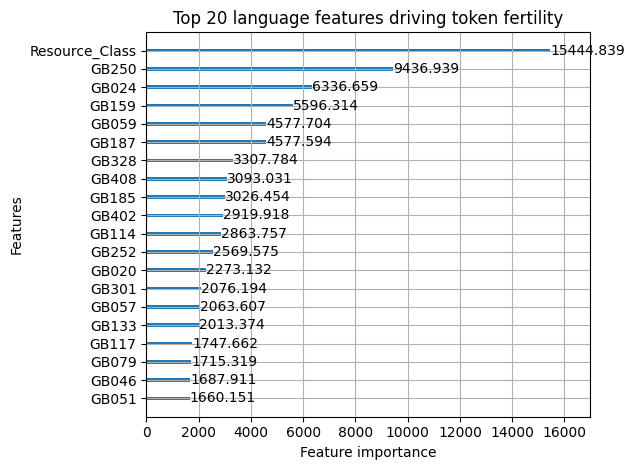

In [30]:
#Show most important features as chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
lgb.plot_importance(
    model,
    importance_type='gain',
    max_num_features=20,
    title = "Top 20 language features driving token fertility"
)
plt.tight_layout()
plt.show()

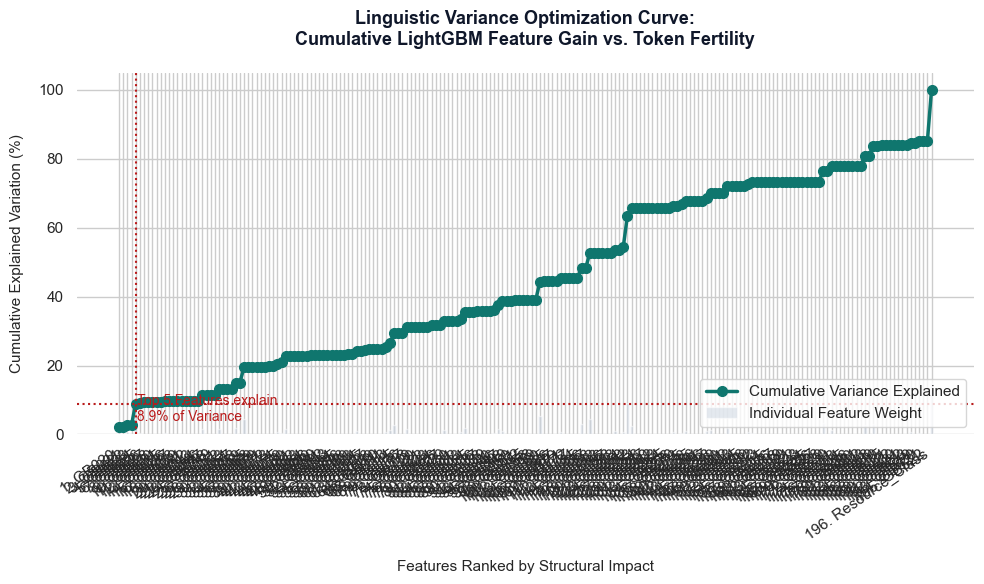

In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

feature_names = model.feature_name_
raw_gains = model.booster_.feature_importance(importance_type='gain')

# 1. Populate your exact LightGBM empirical feature data
feature_data = {
    "Feature_ID": feature_names,
    "Gain_Importance": raw_gains
}

df_features = pd.DataFrame(feature_data)

# 2. Mathematical Normalization & Cumulative Calculations
# Calculate the total gain across this feature subset
total_gain = df_features["Gain_Importance"].sum()

# Convert raw gain numbers into a true relative percentage
df_features["Percentage_Contribution"] = (df_features["Gain_Importance"] / total_gain) * 100

# Compute the step-by-step running running sum (Cumulative Sum)
df_features["Cumulative_Percentage"] = df_features["Percentage_Contribution"].cumsum()

# Create a clean X-axis ranking index string (e.g., "1. Resource_Class")
df_features["Rank_Label"] = [f"{i+1}. {feat}" for i, feat in enumerate(df_features["Feature_ID"])]

# 3. Configure professional plotting canvas
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# 4. Plot the core Cumulative S-Curve line
ax.plot(
    df_features["Rank_Label"], 
    df_features["Cumulative_Percentage"], 
    marker='o', 
    color='#0f766e',      # Deep technical teal
    linewidth=2.5, 
    markersize=7,
    label="Cumulative Variance Explained"
)

# Render a secondary background bar chart to visually emphasize individual feature weight drop-offs
ax.bar(
    df_features["Rank_Label"], 
    df_features["Percentage_Contribution"], 
    color='#cbd5e1',     # Neutral muted gray
    alpha=0.5,
    label="Individual Feature Weight"
)

# 5. Graphically annotate the "elbow point" or inflection line
# Let's flag where the top 5 features cross a major threshold
top_5_cumulative = df_features.loc[4, "Cumulative_Percentage"]
plt.axvline(x=4, color='#b91c1c', linestyle=':', linewidth=1.5) # Dotted red cutoff
plt.axhline(y=top_5_cumulative, color='#b91c1c', linestyle=':', linewidth=1.5)

ax.text(
    4.2, 
    top_5_cumulative - 5, 
    f"Top 5 Features explain\n{top_5_cumulative:.1f}% of Variance", 
    color='#b91c1c', 
    fontweight='medium',
    fontsize=10
)

# 6. Perfect the labels, limits, and clean geometric frames
plt.title(
    "Linguistic Variance Optimization Curve:\nCumulative LightGBM Feature Gain vs. Token Fertility",
    fontsize=13, 
    fontweight="bold", 
    pad=20,
    color="#0f172a"
)
plt.xlabel("Features Ranked by Structural Impact", fontsize=11, labelpad=12)
plt.ylabel("Cumulative Explained Variation (%)", fontsize=11, labelpad=10)

# Force the layout y-axis strictly between 0% and 105% for analytical scaling
plt.ylim(0, 105)

# Rotate labels slightly to prevent layout clipping text boundaries
plt.xticks(rotation=35, ha="right")

ax.legend(loc="lower right", frameon=True)
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 7. Export file for direct integration into your LaTeX document appendix
plt.savefig("feature_cumulative_gain_curve.png", dpi=300)
plt.show()

In [50]:
#Store most important features in dataframe

importance_df = pd.DataFrame({
    'Feature_ID': X.columns,
    'Gain_Importance': model.booster_.feature_importance(importance_type='gain')
})

importance_df = importance_df.sort_values(by='Gain_Importance', ascending=False).reset_index(drop=True)

#importance_df['Feature_Explanation'] = get_question(importance_df['Feature_ID'])

for i in range(len(importance_df)):
    importance_df.loc[importance_df.index[i], 'Feature_Explanation'] = get_question(importance_df.loc[importance_df.index[i], 'Feature_ID'])

print(importance_df.head(20))

importance_df.to_csv("feature_importance.csv")

        Feature_ID  Gain_Importance  \
0   Resource_Class     15444.838547   
1            GB250      9436.939117   
2            GB024      6336.658997   
3            GB159      5596.314407   
4            GB059      4577.704086   
5            GB187      4577.593948   
6            GB328      3307.783997   
7            GB408      3093.031021   
8            GB185      3026.454010   
9            GB402      2919.917999   
10           GB114      2863.756973   
11           GB252      2569.574982   
12           GB020      2273.131821   
13           GB301      2076.193970   
14           GB057      2063.607033   
15           GB133      2013.373993   
16           GB117      1747.662003   
17           GB079      1715.319420   
18           GB046      1687.911407   
19           GB051      1660.151062   

                                  Feature_Explanation  
0                                                      
1   Can predicative possession be expressed with a...  
2    What is

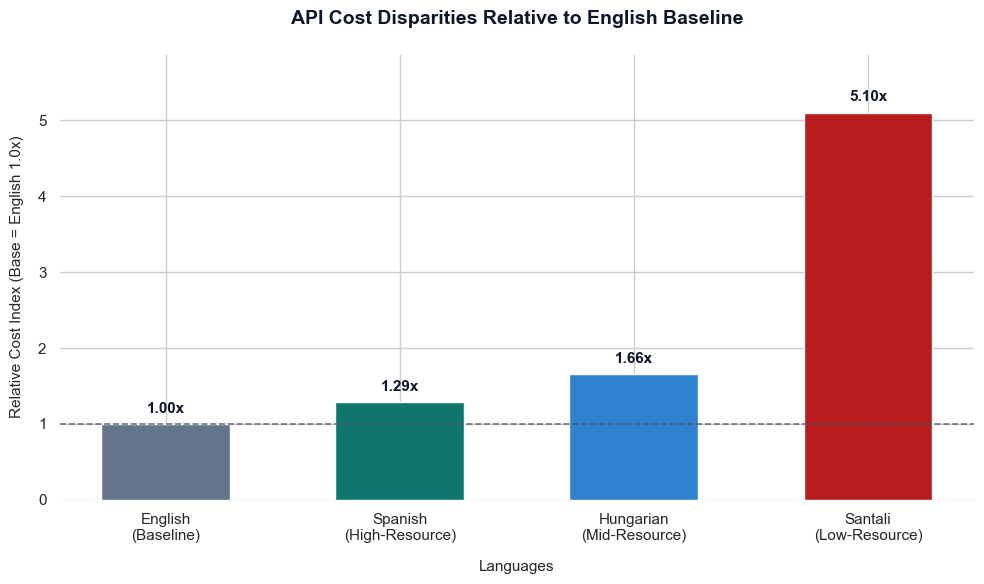

In [93]:
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("sorted_language_tokens.csv")

# FIX 2: Explicitly force the Language_Name column to be strings to prevent float leakages
df["Language_Name"] = df["Language_Name"].astype(str)

# Isolate the precise English benchmark value for the normalization divisor
english_baseline = df.loc[df["Language_Name"] == "English", "Tokens_Per_Sentence"].values[0]

# Compute the exact cost multiplier relative to the baseline
df["Relative_Cost_Multiplier"] = df["Tokens_Per_Sentence"] / english_baseline

# Map labels to include their broader systemic resource classifications
label_mapping = {
    "English": "English\n(Baseline)",
    "Spanish": "Spanish\n(High-Resource)",
    "Hungarian": "Hungarian\n(Mid-Resource)",
    "Santali": "Santali\n(Low-Resource)",
}
df["Formatted_Label"] = df["Language_Name"].map(label_mapping)

condition_mask = df['Language_Name'].isin(["English", "Spanish", "Hungarian", "Santali"])

df = df[condition_mask]

# 2. Configure visualization aesthetics
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Render the comparative histogram bars
colors = ["#64748b", "#0f766e", "#3182ce", "#b91c1c"] # Slate, Teal, Blue, Deep Red
bars = ax.bar(
    df["Formatted_Label"], 
    df["Relative_Cost_Multiplier"], 
    color=colors, 
    width=0.55
)

# 4. Highlight the threshold by drawing an explicit horizontal baseline at 1.0x
plt.axhline(y=1.0, color="#475569", linestyle="--", linewidth=1.2, alpha=0.8)

# 5. Graphically overlay the precise overhead metrics above each column
for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.2f}x",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 6),  # Push the bounding text 6 points vertically above the bar line
        textcoords="offset points",
        ha="center", 
        va="bottom",
        fontweight="bold",
        color="#0f172a",
        fontsize=11
    )

# 6. Tailor titles and layout geometry for academic or professional scrutiny
plt.title(
    "API Cost Disparities Relative to English Baseline",
    fontsize=14, 
    fontweight="bold", 
    pad=22,
    color="#0f172a"
)
plt.ylabel("Relative Cost Index (Base = English 1.0x)", fontsize=11, labelpad=10)
plt.xlabel("Languages", fontsize=11, labelpad=12)

# Set bounds to give text labels comfortable headroom
plt.ylim(0, df["Relative_Cost_Multiplier"].max() * 1.15)

# Strip out distracting canvas spines
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 7. Write to local storage
plt.savefig("market_expansion_exact_comparison.png", dpi=300)
plt.show()

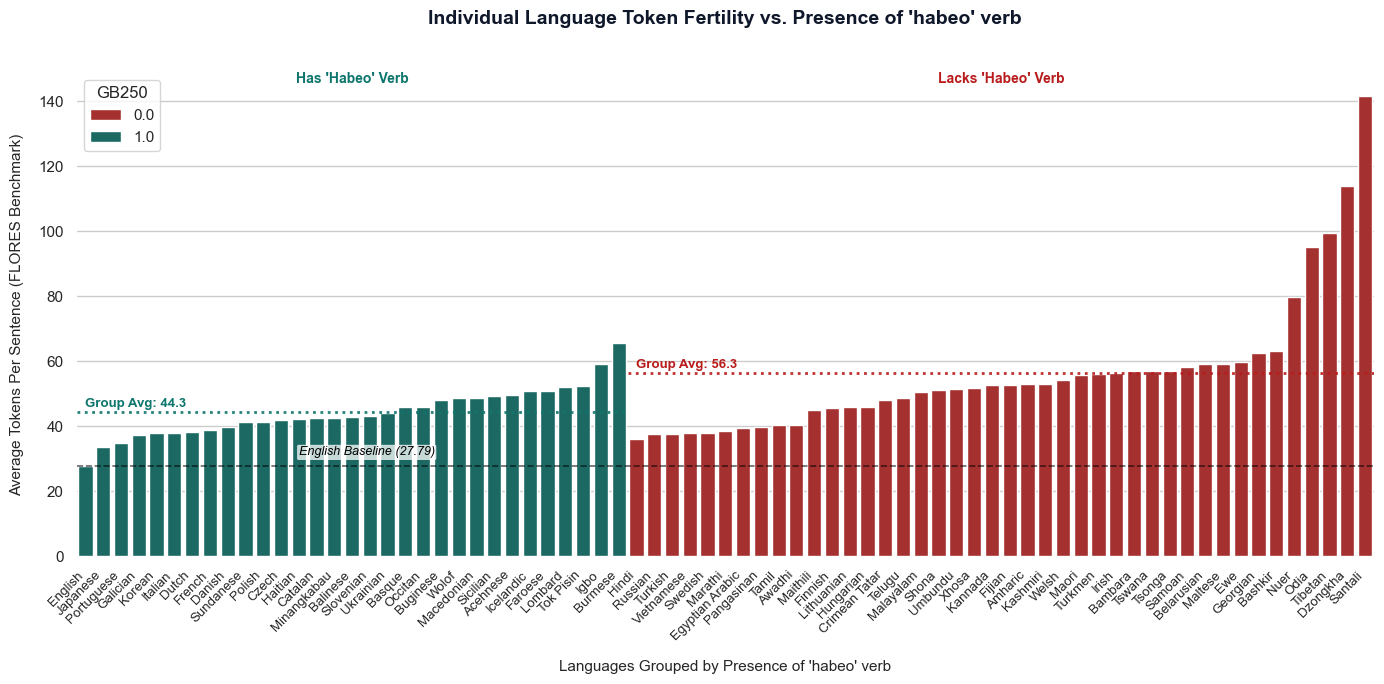

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Load your full dataset 
df = pd.read_csv("full_language_data.csv")

# 2. Sort languages individually within their respective categories
df_yes = df[df["GB250"] == 1.0].sort_values(by="Tokens_Per_Sentence", ascending=True)
df_no = df[df["GB250"] == 0.0].sort_values(by="Tokens_Per_Sentence", ascending=True)

# Calculate group averages for the lines
avg_yes = df_yes["Tokens_Per_Sentence"].mean()
avg_no = df_no["Tokens_Per_Sentence"].mean()

# Recombine them so all 'Yes' bars render first, followed immediately by all 'No' bars
df_sorted = pd.concat([df_yes, df_no]).reset_index(drop=True)
total_languages = len(df_sorted)

# 3. Configure canvas theme and size
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 7))

# 4. Draw the vertical bar plot
colors = {1.0: "#0f766e", 0.0: "#b91c1c"} # Technical Teal vs. Alert Crimson
sns.barplot(
    x="Language_Name",
    y="Tokens_Per_Sentence",
    data=df_sorted,
    hue="GB250",
    palette=colors,
    dodge=False,  
    ax=ax,
    legend= False
)

box_style = dict(
    boxstyle="round,pad=0.1",  # Options: 'square', 'round', 'rarrow', 'larrow'
    facecolor="#ffffff",        # Interior background color (Teal)
    edgecolor="#ffffff",        # Border outline color
    linewidth=0.5,              # Border thickness
    alpha=0.75                  # Transparency (0 = fully clear, 1 = solid)
)

# 5. Add a dashed horizontal reference anchor for the English Baseline
# (Assuming English is in your dataset around 27.79)
plt.axhline(y=27.79, color="#000000", linestyle="--", linewidth=1.2, alpha=0.6)
ax.text(12, 31, "English Baseline (27.79)", color="#000000", fontsize=9, style="italic", bbox=box_style)

# 6. Draw a physical boundary dividing the two halves
split_index = len(df_yes)
#plt.axvline(x=split_index - 0.5, color="#64748b", linestyle="-", linewidth=1.5)

# 7. FIX: Add segmented, dotted horizontal average lines for each half
# xmin and xmax in axhline are specified as fractions of the entire plot width (0.0 to 1.0)
split_fraction = split_index / total_languages

# Left Half Average Line ('Habeo' Present)
ax.axhline(
    y=avg_yes, 
    xmin=0, 
    xmax=split_fraction, 
    color="#0f766e", 
    linestyle=":", 
    linewidth=2, 
    alpha=0.9
)
ax.text(
    0, 
    avg_yes + 1.5, 
    f"Group Avg: {avg_yes:.1f}", 
    color="#0f766e", 
    fontsize=9.5, 
    fontweight="bold"
)

# Right Half Average Line ('Habeo' Absent)
ax.axhline(
    y=avg_no, 
    xmin=split_fraction, 
    xmax=1.0, 
    color="#b91c1c", 
    linestyle=":", 
    linewidth=2, 
    alpha=0.9
)
ax.text(
    split_index, 
    avg_no + 1.5, 
    f"Group Avg: {avg_no:.1f}", 
    color="#b91c1c", 
    fontsize=9.5, 
    fontweight="bold"
)

# 8. Add clear descriptive category titles above each side of the graph
max_y = df_sorted["Tokens_Per_Sentence"].max()
plt.text(
    split_index / 2 - 0.5, 
    max_y * 1.02, 
    "Has 'Habeo' Verb", 
    ha="center", va="bottom", color="#0f766e", fontweight="bold", fontsize=10
)
plt.text(
    split_index + (len(df_no) / 2) - 0.5, 
    max_y * 1.02, 
    "Lacks 'Habeo' Verb", 
    ha="center", va="bottom", color="#b91c1c", fontweight="bold", fontsize=10
)

# 9. Polish layout borders, alignment, and labels
plt.title(
    "Individual Language Token Fertility vs. Presence of 'habeo' verb",
    fontsize=14,
    fontweight="bold",
    pad=35, 
    color="#0f172a"
)
plt.xlabel("Languages Grouped by Presence of 'habeo' verb", fontsize=11, labelpad=12)
plt.ylabel("Average Tokens Per Sentence (FLORES Benchmark)", fontsize=11, labelpad=10)

# Rotate labels slightly to ensure clear string readability
plt.xticks(rotation=45, ha="right", fontsize=9.5)

# Update legend handle labels to show human-readable text instead of numbers
# handles, labels = ax.get_legend_handles_labels()
# ax.legend(handles, ["Present (1.0)", "Absent (0.0)"], title="Transitive 'Habeo' Verb", loc="upper left")

# Strip canvas outline borders
sns.despine(left=True, bottom=True)
plt.tight_layout()

# 10. Export to file
plt.savefig("habeo_split_with_averages.png", dpi=300)
plt.show()

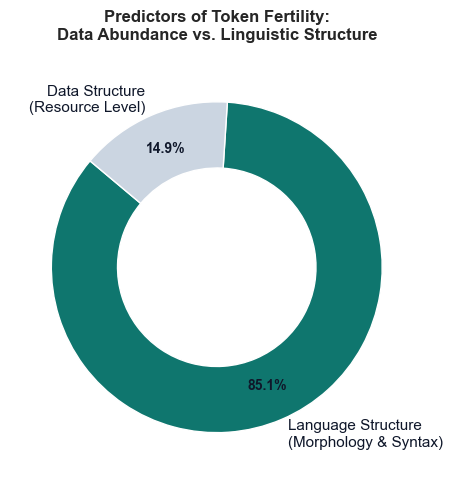

In [86]:
#Resource Class vs. structural language components

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

feature_importance_df = pd.read_csv("feature_importance.csv")
total_gain = 0
resource_gain = feature_importance_df.loc[0,'Gain_Importance']
total_gain += resource_gain
language_structure_gain = 0
for i in range(1, len(feature_importance_df)):
    language_structure_gain += feature_importance_df.loc[i, 'Gain_Importance']
total_gain = resource_gain + language_structure_gain

resource_percent = 100*resource_gain/total_gain
language_structure_percent = 100*language_structure_gain/total_gain


macro_data = {
    "Subsystem": ["Language Structure\n(Morphology & Syntax)", "Data Structure\n(Resource Level)"],
    "Variance_Explained": [language_structure_percent, resource_percent]
}

df_macro = pd.DataFrame(macro_data)

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(6, 5))

colors = ["#0f766e", "#cbd5e1"] # Technical Teal for grammar, muted gray for resource status
wedges, texts, autotexts = ax.pie(
    df_macro["Variance_Explained"], 
    labels=df_macro["Subsystem"],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    colors=colors,
    textprops=dict(color="#0f172a", fontweight="medium"),
    wedgeprops=dict(width=0.4, edgecolor='w') # Creates a clean donut chart layout
)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')
plt.setp(autotexts, size=10, weight="bold")
plt.title("Predictors of Token Fertility:\nData Abundance vs. Linguistic Structure", fontsize=12, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig("predictor_pie_chart.png")
plt.show()